In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

In [9]:
IMG_SIZE = 500

In [10]:
IMG_SIZE = 150

def load_data(data_dir):

    categories = ['PNEUMONIA','NORMAL']
    data = []

    for category in categories:

        path = os.path.join(data_dir, category)
        label = categories.index(category)

        for img_name in os.listdir(path):

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # IMPORTANT

            data.append([img, label])

    return data

In [11]:
data = load_data('train')
np.random.shuffle(data)

In [12]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
y = to_categorical(y, 2)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

IMG_SIZE = 150

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1), name="conv1"),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu', name="conv2"),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu', name="conv3"),  # <- This will be used in Grad-CAM
    MaxPooling2D(2,2),
    
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Run this once to initialize
dummy_input = np.zeros((1, IMG_SIZE, IMG_SIZE, 1))
_ = model.predict(dummy_input)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


In [14]:

# Train the model
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

# Save the model
model.save("virus_model.keras")
print("Model saved as virus_model.keras")



Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.8627 - loss: 0.3263 - val_accuracy: 0.9492 - val_loss: 0.1412
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9540 - loss: 0.1238 - val_accuracy: 0.9741 - val_loss: 0.0922
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.9578 - loss: 0.1178 - val_accuracy: 0.9703 - val_loss: 0.0841
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.9676 - loss: 0.0925 - val_accuracy: 0.9579 - val_loss: 0.1167
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.9734 - loss: 0.0759 - val_accuracy: 0.9713 - val_loss: 0.0793
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9794 - loss: 0.0614 - val_accuracy: 0.9761 - val_loss: 0.0757
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9760 - loss: 0.0591 - val_accuracy: 0.9770 - val_loss: 0.0688
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.9832 - loss: 0

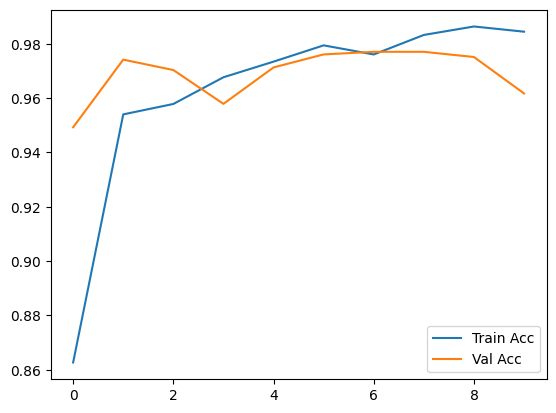

In [15]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()


In [16]:
def predict_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    prediction = model.predict(img)
    return "PNEUMONIA" if np.argmax(prediction) == 0 else "NORMAL"

predict_image("IM-0011-0001.jpeg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


'PNEUMONIA'

In [17]:

model = load_model("virus_model.keras", compile=False)

model.save("virus_model.h5")